# IRIS dataset classification using ANN

In 1936, the British statistician and biologist Ronald Fisher published The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis.

Two of the three species were collected on the Gaspé Peninsula "all from the same pasture, collected on the same day and measured at the same time by the same person with the same instrument".

The dataset consists of 50 samples from each of the three species of iris.

Four traits were measured for each sample: length and width of calyx and petals in centimetres. 

Identification of the fescue species by the dimensions of the different petals

- https://en.wikipedia.org/wiki/Iris_flower_data_set
- https://www.kaggle.com/arshid/iris-flower-dataset

# Task

Your goal is to create a classification neural network to distinguish different species of killer whales.

We will use the same data as in the k-means/SVM chapter, you can build on it.

As you work through this task, the following points will be completed in turn:

- Retrieve the data and display the basic statistics
- Use binary encoding to prepare the data.
- Standardize the input values using StandardScaler
- Split the data into training, test and validation

- Create a neural network model, don't be afraid to experiment with the number of hidden layers and their size
- You will probably need Dense layers, you can try the Drop layer
- Use a relay as the activation function, use a Softmax layer for the output

- When learning, use the categorical_crossentropy cost function
- The optimization algorithm will be ADAM
- You can collect other accuracy metrics

- Save the learned model to a file

- Test the learned model, find R2 and accuracy
- Plot the substitution matrix

- Plot the learning history

- Test the model on your input data (create inference)

# Data retrieval and basic statistics
- data preview
- basic statistics
- NULL values

In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame as df  
data=pd.read_csv('../dataset/IRIS.csv')
#data.dropna()
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [2]:
data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Data visualization
- distribution of values

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

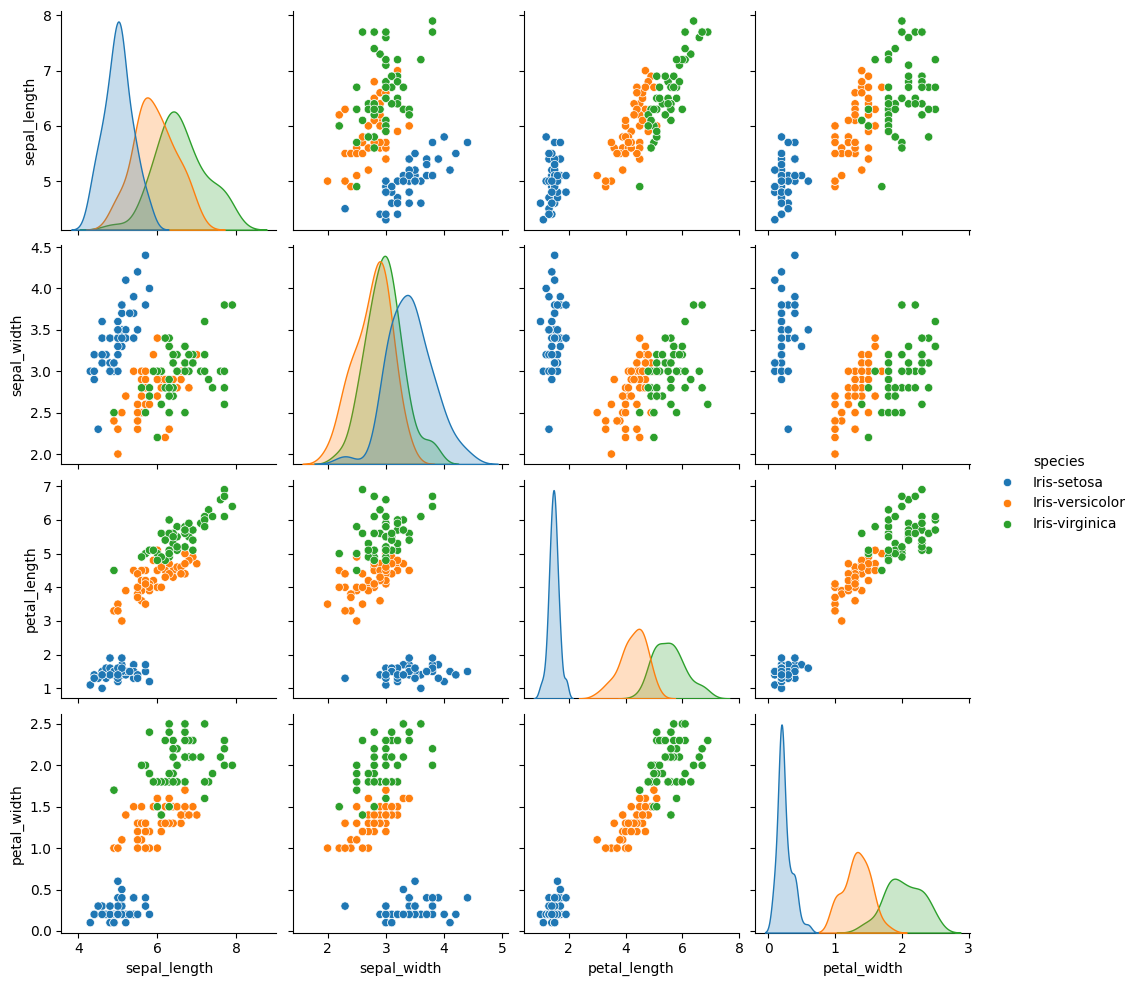

In [5]:
sns.pairplot(data, hue='species', palette=sns.color_palette(n_colors=3))

# Data preparation
- binary encoding
- standardization of input variables

In [6]:
type(data)

pandas.core.frame.DataFrame

In [7]:
# Encoding
species_encoding = {0:'Iris-setosa', 1:'Iris-versicolor', 2:'Iris-virginica'}
species_encoding_inverse = { item[1]:item[0] for item in species_encoding.items()}
data['species_enc']= data['species'].apply(lambda x: species_encoding_inverse[x])
data = data.drop(columns=['species'])
data

,sepal_length,sepal_width,petal_length,petal_width,species_enc
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
import re
#word = "specincesSTD"
regexPattern = re.compile(r'(STD)|(enc)')
#if regexp.search(word):
#    print("match", word)

In [9]:
for i in data.columns:
    if i == 'species_enc':
        continue
    #if i == 'species':
    #    continue
    data[i+'_STD'] = (data[i] - data[i].mean())/data[i].std()
data.describe()
toDrop = list()
for i in data.columns:
    if not (regexPattern.search(i)):
        toDrop += [i]
data = data.drop(columns=toDrop)
data.describe()

,species_enc,sepal_length_STD,sepal_width_STD,petal_length_STD,petal_width_STD
count,150.000000,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,1.000000,-5.684342e-16,-6.158037e-16,1.894781e-16,-1.894781e-16
std,0.819232,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,0.000000,-1.863780e+00,-2.430844e+00,-1.563497e+00,-1.439627e+00
25%,0.000000,-8.976739e-01,-5.858010e-01,-1.223442e+00,-1.177559e+00
50%,1.000000,-5.233076e-02,-1.245404e-01,3.351431e-01,1.327811e-01
75%,2.000000,6.722490e-01,5.673506e-01,7.602119e-01,7.879511e-01
max,2.000000,2.483699e+00,3.104284e+00,1.780377e+00,1.705189e+00


In [10]:
# Spliting data to training data and other
X = data[['sepal_length_STD', 'sepal_width_STD', 'petal_length_STD', 'petal_width_STD']]
Y = df({key:np.where(data['species_enc'] ==  species_encoding_inverse[key], 1, 0) for key in species_encoding_inverse})
Y


,Iris-setosa,Iris-versicolor,Iris-virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
145,0,0,1
146,0,0,1
147,0,0,1
148,0,0,1


In [11]:
from sklearn.model_selection import train_test_split
def split_dataset (X, Y, train_ratio = 0.75, validation_ratio = 0.15, test_ratio = 0.10):
#def split_dataset (X, Y, train_ratio = 0.98, validation_ratio = 0.01, test_ratio = 0.01):
    """ Slitting the dataset into training, validation and testing subset
        X - explanatory variables
        Y - explained variables

        train_ratio      - training data ratio
        validation_ratio - validation data ratio
        test_ratio       - ratio of test data

    """
    assert(train_ratio + validation_ratio + test_ratio == 1.0)

    # train now makes up 75% of the entire data set
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1 - train_ratio)

    # test is now 10% of the original data set
    # is now 15% of the original data set
    X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size=test_ratio/(test_ratio + validation_ratio)) 
    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [12]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = split_dataset(X, Y, train_ratio = 0.75, validation_ratio = 0.00, test_ratio = 0.25)

InvalidParameterError: The 'test_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 1.0 instead.

## Neural network modelling

Neural network model
* Sequential model - data flows from the input layer through hidden layers to the output layer.
* Dense layer connects each neuron from the previous layer to each neuron in the layer.
* Drop layer randomly sets the input units to 0 at each step during the training period, which helps prevent overfitting.
* RELU and Softmax activation functions are used. 
* The last Softmax function is used in the output layer because this project is a classification project.

* Compilation is the last step in model building.
* The optimizer we use is Adam. Adam is an optimization algorithm that can be used instead of the classical stochastic gradient descent procedure to iteratively update the network weights based on the training data.
* Cost function - categorical_crossentropy, a special loss function for classification (https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class).
* Another metric - Accuracy - is computed during learning.


Model: "sequential"
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80                                                                         
 dropout (Dropout)           (None, 16)                0                                                                          
 dense_1 (Dense)             (None, 16)                272                                                                        
 dropout_1 (Dropout)         (None, 16)                0                                                                          
 dense_2 (Dense)             (None, 3)                 51        
                                                                 
Total params: 403
Trainable params: 403
Non-trainable params: 0

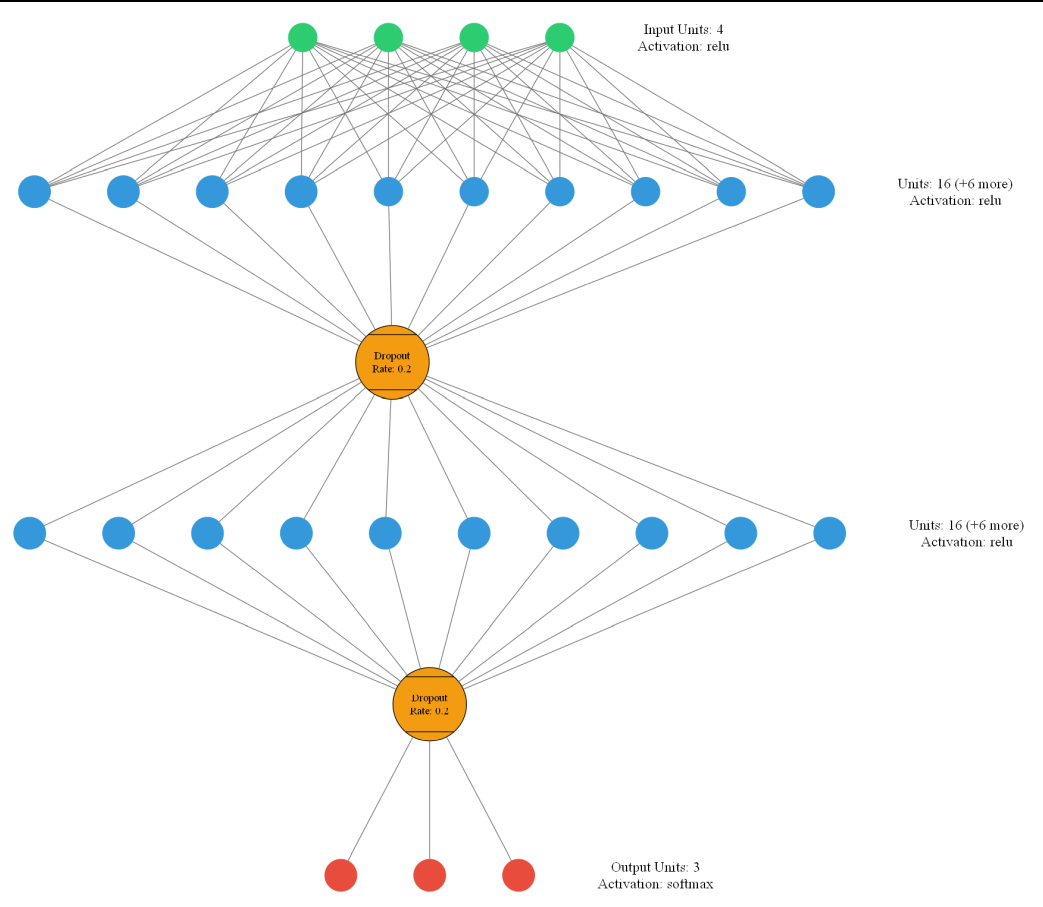

In [ ]:
import keras
from keras.layers import Dense, Dropout, Activation, Input
from keras.models import Sequential

In [ ]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(16, activation = 'relu'))
model.add(Dropout(rate=0.05))
model.add(Dense(16, activation = 'relu'))
model.add(Dropout(rate=0.05))
model.add(Dense(3, activation = 'softmax'))
model.compile(optimizer="adam", loss="mse", metrics=["mae"]) #

In [ ]:
model.compile(loss = "categorical_crossentropy",
                optimizer = "adam",
                metrics = ["accuracy"]
                )

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='accuracy', patience=30)
history=model.fit(X_train, Y_train, epochs=1000, batch_size=5, callbacks=[early_stop])

# Save the model

In [ ]:
model.save('iris_model.keras')

# Show learning history

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Počet epoch')
plt.show()


# Model Verification
- Prediction of test values
- Accuracy
- Confusion matrix of training and test data

In [ ]:
Y_pred = model.predict(X_test)
Y_train_pred = model.predict(X_train)

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, Y_pred)
print('R2 score: {}'.format(r2))
r2_train = r2_score(Y_train, Y_train_pred)
print('R2_train score: {}'.format(r2_train))

In [ ]:
X_test = X
Y_test = Y
data_predicted = X_test[['sepal_length_STD', 'sepal_width_STD', 'petal_length_STD', 'petal_width_STD']]
data_predicted['species_pred'] = [i.argmax() for i in model.predict(data_predicted)]
X_test['species_enc'] = [i.argmax() for i in Y_test.to_numpy()]

sns.pairplot(X_test, hue='species_enc', palette=sns.color_palette(n_colors=3))
sns.pairplot(data_predicted, hue='species_pred', palette=sns.color_palette(n_colors=3))


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cf_matrix=confusion_matrix(X_test['species_enc'], data_predicted['species_pred'])
sns.heatmap(cf_matrix, annot=True)

# Using the model
The answer should therefore be Iris virginica

In [ ]:
test_predictions = model.predict(df([[1,2,1,2]]))
#species_encoding_inverse
print (f"Iris setosa:     {test_predictions[0][species_encoding_inverse['Iris-setosa']]}")
print (f"Iris versicolor: {test_predictions[0][species_encoding_inverse['Iris-versicolor']]}")
print (f"Iris virginica:  {test_predictions[0][species_encoding_inverse['Iris-virginica']]}")

# Slow end stupid solution for finding max, can be improved.
max = 0.0
species = 'None'
for i in species_encoding_inverse:
    if max < test_predictions[0][species_encoding_inverse[i]]:
        max = test_predictions[0][species_encoding_inverse[i]]
        species = i
print('Flover is ',  species, '.', sep = '')